In [1]:
from pathlib import Path
import json
from collections import defaultdict
from typing import List, Dict, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
from metrics import *


def ranking(
    dataset: str,
    model: str,
) -> None:
    """
    Compute and print ranking of FrogDQ modes based on experiment results.

    Parameters
    ----------
    dataset : str
        Dataset name used in experiments.
    model : str
        Model architecture (matches key "model_type").
    """
    # Resolve experiment results path (repo root)
    results_path = Path("results/Adult/experiment_results.json")

    if not results_path.exists():
        print(f"File not found: {results_path}")
        return

    # Read JSON with robust fallbacks
    try:
        text = results_path.read_text(encoding="utf-8")
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    if not text.strip():
        print("Results file is empty.")
        return

    try:
        payload = json.loads(text)
    except json.JSONDecodeError as e:
        print(f"Invalid JSON: {e}")
        return

    # Support two shapes: {"experiments": [...]} or a raw list [...]
    if isinstance(payload, dict) and "experiments" in payload and isinstance(payload["experiments"], list):
        experiments = payload["experiments"]
    elif isinstance(payload, list):
        experiments = payload
    else:
        print('Unrecognized results structure. Expecting {"experiments": [...]} or a list.')
        return

    # Filter experiments by parameters
    def _match(exp: Dict) -> bool:
        return (
            exp.get("dataset") == dataset
            and exp.get("model_type") == model
        )

    filtered: List[Dict] = [exp for exp in experiments if _match(exp)]

    if not filtered:
        print("No experiments matched the provided filters.")
        return

    # ---- Helper functions ----------------------------------------------------
    def _ensure_float_list(seq) -> Optional[List[float]]:
        if not isinstance(seq, list) or len(seq) == 0:
            return None
        out = []
        for x in seq:
            if x is None:
                out.append(np.nan)
            else:
                try:
                    out.append(float(x))
                except (TypeError, ValueError):
                    out.append(np.nan)
        return out

    def _last_finite(value_or_list) -> Optional[float]:
        """
        Accepts either a scalar or a list. If list, returns the last finite value.
        If scalar, returns it if finite. Otherwise None.
        """
        if isinstance(value_or_list, list):
            arr = _ensure_float_list(value_or_list)
            if not arr:
                return None
            # walk backward to find last finite
            for v in reversed(arr):
                if np.isfinite(v):
                    return float(v)
            return None
        # scalar:
        try:
            v = float(value_or_list)
        except (TypeError, ValueError):
            return None
        return float(v) if np.isfinite(v) else None

    # ---- Aggregate validation histories & build new metrics -----------------------
    val_curves_by_mode: Dict[str, Dict[str, List[List[float]]]] = defaultdict(lambda: defaultdict(list))
    val_scalar_metrics_by_mode: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: defaultdict(list))
    for exp in filtered:
        mode = exp.get("frogdq_mode", "unknown")
        hist = (exp.get("history") or {})
        for val_curve in ["val_loss", "val_acc", "val_bal_acc", "val_f1", "val_auc"]:
            if val_curve not in hist:
                continue
            seq = hist.get(val_curve)
            seq = _ensure_float_list(seq)
            if seq:
                val_curves_by_mode[mode][val_curve].append(seq)
                if val_curve in ["val_acc", "val_bal_acc", "val_f1"]:
                    val_scalar_metrics_by_mode[mode][f"auc_conv_{val_curve}"].append(auc_conv(metric_values=seq))
                    val_scalar_metrics_by_mode[mode][f"epochs_to_impr_{val_curve}"].append(epochs_to_impr_acc(metric_values=seq))
                    val_scalar_metrics_by_mode[mode][f"max_{val_curve}"].append(max_value(metric_values=seq))
                elif val_curve == "val_auc":
                    val_scalar_metrics_by_mode[mode][f"max_{val_curve}"].append(max_value(metric_values=seq))

    # ---- Aggregate test metrics &  -------------------------------
    test_metric_keys = [
        "test_loss",
        "test_acc",
        "test_bal_acc",
        "test_f1",
        "test_auc",
    ]
    # per-mode -> per-metric -> list of scalars
    test_values_by_mode: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: defaultdict(list))

    for exp in filtered:
        mode = exp.get("frogdq_mode", "unknown")
        hist = (exp.get("history") or {})
        for k in test_metric_keys:
            v = hist.get(k)
            final_v = _last_finite(v)
            if final_v is not None and np.isfinite(final_v):
                test_values_by_mode[mode][k].append(final_v)

    # ---- Compute elementwise means and CIs for validation curves --------------
    def elementwise_mean_ci(sequences: List[List[float]], z: float = 1.96):
        """
        Compute elementwise mean and CI (mean ± z * SE) for a list of equal or variable-length sequences.
        Returns: mean_curve, lower_bound, upper_bound
        """
        max_len = max(len(s) for s in sequences)
        means, lowers, uppers = [], [], []
        for i in range(max_len):
            vals = [s[i] for s in sequences if i < len(s) and np.isfinite(s[i])]
            if len(vals) == 0:
                # repeat last known values if missing
                means.append(means[-1] if means else np.nan)
                lowers.append(lowers[-1] if lowers else np.nan)
                uppers.append(uppers[-1] if uppers else np.nan)
            else:
                m = float(np.mean(vals))
                sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
                se = sd / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
                lo, hi = m - z * se, m + z * se
                means.append(m)
                lowers.append(lo)
                uppers.append(hi)
        return means, lowers, uppers
    

    # ---- Compute per-mode mean metrics and ranking -------------------------------
    mean_validation_curves: Dict[str, Dict[str, List[float]]] = defaultdict(dict)
    per_mode_metric_means: Dict[str, Dict[str, float]] = defaultdict(dict)

    for mode, metrics_by_curve in val_curves_by_mode.items():
        for metric_name, sequences in metrics_by_curve.items():
            if not sequences:
                continue
            try:
                mean_curve, _, _ = elementwise_mean_ci(sequences)
            except ValueError:
                continue
            mean_validation_curves[mode][metric_name] = mean_curve
            final_val = _last_finite(mean_curve)
            if final_val is not None and np.isfinite(final_val):
                per_mode_metric_means[mode][metric_name] = float(final_val)

    for mode, metrics_dict in val_scalar_metrics_by_mode.items():
        for metric_name, values in metrics_dict.items():
            clean = [float(v) for v in values if v is not None and np.isfinite(v)]
            if not clean:
                continue
            per_mode_metric_means[mode][metric_name] = float(np.mean(clean))

    for mode, metrics_dict in test_values_by_mode.items():
        for metric_name, values in metrics_dict.items():
            clean = [float(v) for v in values if v is not None and np.isfinite(v)]
            if not clean:
                continue
            per_mode_metric_means[mode][metric_name] = float(np.mean(clean))

    if not per_mode_metric_means:
        print("No aggregate metrics available after processing.")
        return

    metrics_order = [
        "val_loss",
        "val_acc",
        "val_bal_acc",
        "val_f1",
        "val_auc",
        "max_val_acc",
        "max_val_bal_acc",
        "max_val_f1",
        "max_val_auc",
        "auc_conv_val_acc",
        "auc_conv_val_bal_acc",
        "auc_conv_val_f1",
        "epochs_to_impr_val_acc",
        "epochs_to_impr_val_bal_acc",
        "epochs_to_impr_val_f1",
        "test_loss",
        "test_acc",
        "test_bal_acc",
        "test_f1",
        "test_auc",
    ]

    higher_is_better = {
        "val_loss": False,
        "test_loss": False,
        "epochs_to_impr_val_acc": False,
        "epochs_to_impr_val_bal_acc": False,
        "epochs_to_impr_val_f1": False,
    }

    all_modes = sorted(per_mode_metric_means.keys())

    metric_to_mode_values: Dict[str, Dict[str, float]] = defaultdict(dict)
    for mode, metric_values in per_mode_metric_means.items():
        for metric_name, value in metric_values.items():
            metric_to_mode_values[metric_name][mode] = value

    print("\nPer-mode mean metrics:")
    for mode in all_modes:
        metrics_present = per_mode_metric_means.get(mode, {})
        if not metrics_present:
            continue
        print(f"\n[{mode}]")
        for metric in metrics_order:
            if metric not in metrics_present:
                continue
            value = metrics_present[metric]
            print(f"  {metric}: {value:.4f}")

    print("\nRanking by metric (best to worst):")
    metric_labels: List[str] = []
    rank_rows: List[List[float]] = []
    value_rows: List[List[float]] = []

    for metric in metrics_order:
        mode_values = metric_to_mode_values.get(metric)
        if not mode_values:
            continue
        clean_items = [
            (mode, value)
            for mode, value in mode_values.items()
            if value is not None and np.isfinite(value)
        ]
        if not clean_items:
            continue
        direction_desc = "higher" if higher_is_better.get(metric, True) else "lower"
        print(f"\n- {metric} ({direction_desc} is better)")
        reverse = higher_is_better.get(metric, True)
        sorted_modes = sorted(clean_items, key=lambda kv: kv[1], reverse=reverse)
        mode_to_rank = {}
        for idx, (mode, value) in enumerate(sorted_modes, start=1):
            print(f"  {idx}. {mode}: {value:.4f}")
            mode_to_rank[mode] = idx

        metric_labels.append(metric)
        row_ranks = [np.nan] * len(all_modes)
        row_values = [np.nan] * len(all_modes)
        for col_idx, mode in enumerate(all_modes):
            value = mode_values.get(mode)
            if value is None or not np.isfinite(value):
                continue
            row_values[col_idx] = value
            rank = mode_to_rank.get(mode)
            if rank is not None:
                row_ranks[col_idx] = float(rank)
        rank_rows.append(row_ranks)
        value_rows.append(row_values)

    if not metric_labels:
        print("No metrics available for ranking.")
        return

    rank_matrix = np.array(rank_rows, dtype=float)
    value_matrix = np.array(value_rows, dtype=float)

    base_cmap = plt.cm.get_cmap("viridis_r")
    cmap = base_cmap.copy() if hasattr(base_cmap, "copy") else base_cmap
    cmap.set_bad(color="lightgray")

    fig, ax = plt.subplots(figsize=(1.6 * len(all_modes) + 1.5, 0.45 * len(metric_labels) + 1.5))
    masked_ranks = np.ma.masked_invalid(rank_matrix)
    im = ax.imshow(masked_ranks, cmap=cmap, aspect="auto", vmin=1, vmax=np.nanmax(rank_matrix))

    ax.set_xticks(range(len(all_modes)))
    ax.set_xticklabels(all_modes, rotation=45, ha="right")
    ax.set_yticks(range(len(metric_labels)))
    ax.set_yticklabels(metric_labels)
    ax.set_title("FrogDQ mode ranking per metric")

    min_rank = np.nanmin(rank_matrix)
    max_rank = np.nanmax(rank_matrix)
    rank_midpoint = (min_rank + max_rank) / 2 if np.isfinite(min_rank) and np.isfinite(max_rank) else np.nan

    for i in range(rank_matrix.shape[0]):
        for j in range(rank_matrix.shape[1]):
            rank_val = rank_matrix[i, j]
            if not np.isfinite(rank_val):
                continue
            metric_val = value_matrix[i, j]
            text_color = "white" if np.isfinite(rank_midpoint) and rank_val <= rank_midpoint else "black"
            if np.isfinite(metric_val):
                ax.text(j, i, f"{int(rank_val)}\n{metric_val:.3f}", ha="center", va="center", color=text_color, fontsize=8)
            else:
                ax.text(j, i, f"{int(rank_val)}", ha="center", va="center", color=text_color, fontsize=8)

    fig.colorbar(im, ax=ax, label="Rank (1 = best)")
    plt.tight_layout()
    plt.show()



In [2]:
from pathlib import Path
import json
from collections import defaultdict
from typing import List, Dict, Optional, Tuple
import numpy as np
import matplotlib.pyplot as plt
from metrics import *
from model import parse_frogdq_mode, FROGDQ_ALLOWED_MODULES


def module_impact(dataset: str, model: str) -> None:
    """
    Compute and print delta impact of FrogDQ modules.

    Parameters
    ----------
    dataset : str
        Dataset name used in experiments.
    model : str
        Model architecture (matches key "model_type").
    """
    # Resolve experiment results path (repo root)
    results_path = Path("results/Adult/experiment_results.json")

    if not results_path.exists():
        print(f"File not found: {results_path}")
        return

    # Read JSON with robust fallbacks
    try:
        text = results_path.read_text(encoding="utf-8")
    except Exception as e:
        print(f"Could not read results file: {e}")
        return

    if not text.strip():
        print("Results file is empty.")
        return

    try:
        payload = json.loads(text)
    except json.JSONDecodeError as e:
        print(f"Invalid JSON: {e}")
        return

    # Support two shapes: {"experiments": [...]} or a raw list [...]
    if isinstance(payload, dict) and "experiments" in payload and isinstance(payload["experiments"], list):
        experiments = payload["experiments"]
    elif isinstance(payload, list):
        experiments = payload
    else:
        print('Unrecognized results structure. Expecting {"experiments": [...]} or a list.')
        return

    # Filter experiments by parameters
    def _match(exp: Dict) -> bool:
        return exp.get("dataset") == dataset and exp.get("model_type") == model

    filtered: List[Dict] = [exp for exp in experiments if _match(exp)]

    if not filtered:
        print("No experiments matched the provided filters.")
        return

    # ---- Helper functions ----------------------------------------------------
    def _ensure_float_list(seq) -> Optional[List[float]]:
        if not isinstance(seq, list) or len(seq) == 0:
            return None
        out = []
        for x in seq:
            if x is None:
                out.append(np.nan)
            else:
                try:
                    out.append(float(x))
                except (TypeError, ValueError):
                    out.append(np.nan)
        return out

    def _last_finite(value_or_list) -> Optional[float]:
        """
        Accepts either a scalar or a list. If list, returns the last finite value.
        If scalar, returns it if finite. Otherwise None.
        """
        if isinstance(value_or_list, list):
            arr = _ensure_float_list(value_or_list)
            if not arr:
                return None
            for v in reversed(arr):
                if np.isfinite(v):
                    return float(v)
            return None
        try:
            v = float(value_or_list)
        except (TypeError, ValueError):
            return None
        return float(v) if np.isfinite(v) else None

    # ---- Aggregate validation histories & build new metrics -----------------------
    val_curves_by_mode: Dict[str, Dict[str, List[List[float]]]] = defaultdict(lambda: defaultdict(list))
    val_scalar_metrics_by_mode: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: defaultdict(list))

    for exp in filtered:
        mode = exp.get("frogdq_mode", "unknown")
        hist = (exp.get("history") or {})
        for val_curve in ["val_loss", "val_acc", "val_bal_acc", "val_f1", "val_auc"]:
            if val_curve not in hist:
                continue
            seq = hist.get(val_curve)
            seq = _ensure_float_list(seq)
            if seq:
                val_curves_by_mode[mode][val_curve].append(seq)
                if val_curve in ["val_acc", "val_bal_acc", "val_f1"]:
                    val_scalar_metrics_by_mode[mode][f"auc_conv_{val_curve}"].append(auc_conv(metric_values=seq))
                    val_scalar_metrics_by_mode[mode][f"epochs_to_impr_{val_curve}"].append(epochs_to_impr_acc(metric_values=seq))
                    val_scalar_metrics_by_mode[mode][f"max_{val_curve}"].append(max_value(metric_values=seq))
                elif val_curve == "val_auc":
                    val_scalar_metrics_by_mode[mode][f"max_{val_curve}"].append(max_value(metric_values=seq))

    # ---- Aggregate test metrics -------------------------------
    test_metric_keys = [
        "test_loss",
        "test_acc",
        "test_bal_acc",
        "test_f1",
        "test_auc",
    ]
    test_values_by_mode: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: defaultdict(list))

    for exp in filtered:
        mode = exp.get("frogdq_mode", "unknown")
        hist = (exp.get("history") or {})
        for k in test_metric_keys:
            v = hist.get(k)
            final_v = _last_finite(v)
            if final_v is not None and np.isfinite(final_v):
                test_values_by_mode[mode][k].append(final_v)

    # ---- Compute elementwise means and CIs for validation curves --------------
    def elementwise_mean_ci(sequences: List[List[float]], z: float = 1.96):
        """
        Compute elementwise mean and CI (mean ± z * SE) for a list of equal or variable-length sequences.
        Returns: mean_curve, lower_bound, upper_bound
        """
        max_len = max(len(s) for s in sequences)
        means, lowers, uppers = [], [], []
        for i in range(max_len):
            vals = [s[i] for s in sequences if i < len(s) and np.isfinite(s[i])]
            if len(vals) == 0:
                means.append(means[-1] if means else np.nan)
                lowers.append(lowers[-1] if lowers else np.nan)
                uppers.append(uppers[-1] if uppers else np.nan)
            else:
                m = float(np.mean(vals))
                sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
                se = sd / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
                lo, hi = m - z * se, m + z * se
                means.append(m)
                lowers.append(lo)
                uppers.append(hi)
        return means, lowers, uppers

    # ---- Compute per-mode mean metrics -------------------------------
    per_mode_metric_means: Dict[str, Dict[str, float]] = defaultdict(dict)

    for mode, metrics_by_curve in val_curves_by_mode.items():
        for metric_name, sequences in metrics_by_curve.items():
            if not sequences:
                continue
            try:
                mean_curve, _, _ = elementwise_mean_ci(sequences)
            except ValueError:
                continue
            final_val = _last_finite(mean_curve)
            if final_val is not None and np.isfinite(final_val):
                per_mode_metric_means[mode][metric_name] = float(final_val)

    for mode, metrics_dict in val_scalar_metrics_by_mode.items():
        for metric_name, values in metrics_dict.items():
            clean = [float(v) for v in values if v is not None and np.isfinite(v)]
            if not clean:
                continue
            per_mode_metric_means[mode][metric_name] = float(np.mean(clean))

    for mode, metrics_dict in test_values_by_mode.items():
        for metric_name, values in metrics_dict.items():
            clean = [float(v) for v in values if v is not None and np.isfinite(v)]
            if not clean:
                continue
            per_mode_metric_means[mode][metric_name] = float(np.mean(clean))

    if not per_mode_metric_means:
        print("No aggregate metrics available after processing.")
        return

    metrics_order = [
        "val_loss",
        "val_acc",
        "val_bal_acc",
        "val_f1",
        "val_auc",
        "max_val_acc",
        "max_val_bal_acc",
        "max_val_f1",
        "max_val_auc",
        "auc_conv_val_acc",
        "auc_conv_val_bal_acc",
        "auc_conv_val_f1",
        "epochs_to_impr_val_acc",
        "epochs_to_impr_val_bal_acc",
        "epochs_to_impr_val_f1",
        "test_loss",
        "test_acc",
        "test_bal_acc",
        "test_f1",
        "test_auc",
    ]

    higher_is_better = {
        "val_loss": False,
        "test_loss": False,
        "epochs_to_impr_val_acc": False,
        "epochs_to_impr_val_bal_acc": False,
        "epochs_to_impr_val_f1": False,
    }

    modules_to_track = list(FROGDQ_ALLOWED_MODULES)
    module_metric_values: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: defaultdict(list))
    baseline_metric_values: Dict[str, List[float]] = defaultdict(list)

    for mode, metrics_dict in per_mode_metric_means.items():
        try:
            modules_info = parse_frogdq_mode(mode)
        except ValueError as exc:
            print(f"Skipping mode '{mode}': {exc}")
            continue

        if modules_info.canonical == "none":
            for metric_name, value in metrics_dict.items():
                if value is None or not np.isfinite(value):
                    continue
                baseline_metric_values[metric_name].append(float(value))
            continue

        if not modules_info.active:
            continue

        for metric_name, value in metrics_dict.items():
            if value is None or not np.isfinite(value):
                continue
            for module in modules_info.active:
                if module in modules_to_track:
                    module_metric_values[module][metric_name].append(float(value))

    baseline_means: Dict[str, float] = {}
    for metric_name, values in baseline_metric_values.items():
        clean = [v for v in values if np.isfinite(v)]
        if clean:
            baseline_means[metric_name] = float(np.mean(clean))

    if not baseline_means:
        print("No baseline 'none' mode found; cannot compute module impacts.")
        return

    module_metric_means: Dict[str, Dict[str, float]] = {}
    module_impacts: Dict[str, Dict[str, float]] = defaultdict(dict)

    for module in modules_to_track:
        metrics_dict = module_metric_values.get(module)
        if not metrics_dict:
            continue
        module_metric_means[module] = {}
        for metric_name, values in metrics_dict.items():
            clean = [v for v in values if np.isfinite(v)]
            if not clean:
                continue
            mean_val = float(np.mean(clean))
            module_metric_means[module][metric_name] = mean_val
            baseline_val = baseline_means.get(metric_name)
            if baseline_val is not None:
                module_impacts[module][metric_name] = mean_val - baseline_val

    if not module_metric_means:
        print("No module-level metrics available after processing.")
        return

    print("\nBaseline (frogdq_mode='none') mean metrics:")
    for metric in metrics_order:
        baseline_val = baseline_means.get(metric)
        if baseline_val is None:
            continue
        print(f"  {metric}: {baseline_val:.4f}")

    print("\nModule mean metrics and deltas vs 'none':")
    for module in modules_to_track:
        metrics_dict = module_metric_means.get(module)
        if not metrics_dict:
            continue
        print(f"\n[{module}]")
        for metric in metrics_order:
            if metric not in metrics_dict:
                continue
            mean_val = metrics_dict[metric]
            delta_val = module_impacts.get(module, {}).get(metric)
            delta_str = f" ({delta_val:+.4f} vs none)" if delta_val is not None else ""
            print(f"  {metric}: {mean_val:.4f}{delta_str}")

    print("\nModule impact ranking per metric:")
    metric_rankings: Dict[str, List[Tuple[str, float, float]]] = {}
    for metric in metrics_order:
        baseline_val = baseline_means.get(metric)
        if baseline_val is None:
            continue
        entries = []
        for module in modules_to_track:
            impact_val = module_impacts.get(module, {}).get(metric)
            if impact_val is None or not np.isfinite(impact_val):
                continue
            score = impact_val if higher_is_better.get(metric, True) else -impact_val
            entries.append((module, impact_val, score))
        if not entries:
            continue
        direction_desc = "higher" if higher_is_better.get(metric, True) else "lower"
        print(f"\n- {metric} (baseline none = {baseline_val:.4f}; {direction_desc} is better)")
        entries.sort(key=lambda item: item[2], reverse=True)
        metric_rankings[metric] = entries
        for rank_idx, (module, impact_val, _) in enumerate(entries, start=1):
            mean_val = module_metric_means[module][metric]
            print(f"  {rank_idx}. {module}: Δ {impact_val:+.4f} (mean {mean_val:.4f})")

    metric_plots = [(metric, metric_rankings[metric]) for metric in metrics_order if metric in metric_rankings]
    if metric_plots:
        n_metrics = len(metric_plots)
        ncols = min(3, n_metrics) if n_metrics > 1 else 1
        nrows = (n_metrics + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
        axes = axes.flatten()
        for idx, (metric, entries) in enumerate(metric_plots):
            ax = axes[idx]
            modules = [item[0] for item in entries]
            impacts = [item[1] for item in entries]
            better_is_higher = higher_is_better.get(metric, True)
            colors = []
            for impact in impacts:
                improved = impact >= 0 if better_is_higher else impact <= 0
                colors.append("#2ca02c" if improved else "#d62728")
            ax.bar(range(len(modules)), impacts, color=colors)
            ax.axhline(0.0, color="#333333", linewidth=0.8)
            ax.set_xticks(range(len(modules)))
            ax.set_xticklabels(modules, rotation=45, ha="right")
            ax.set_title(f"{metric} Δ vs none")
            direction_desc = "higher" if better_is_higher else "lower"
            ax.set_ylabel("Δ")
            ax.set_xlabel(f"Modules (better = {direction_desc})")
        for ax in axes[len(metric_plots):]:
            ax.remove()
        fig.tight_layout()
        plt.show()


2025-11-05 09:28:05.111 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 76.
2025-11-05 09:28:05.111 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 76.
2025-11-05 09:28:05.112 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 76.
2025-11-05 09:28:05.112 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 101.
2025-11-05 09:28:05.112 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 101.
2025-11-05 09:28:05.112 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 101.
2025-11-05 09:28:05.113 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 101.
2025-11-05 09:28:05.113 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 101.
2025-11-05 09:28:05.113 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 101.
2025-11-05 09:28:05.113 | INFO     | metrics:auc_conv:69 - Convergence reach


Baseline (frogdq_mode='none') mean metrics:
  val_loss: 0.3917
  val_acc: 0.8026
  val_bal_acc: 0.8104
  val_f1: 0.7632
  val_auc: 0.8989
  max_val_acc: 0.7813
  max_val_bal_acc: 0.8011
  max_val_f1: 0.7437
  max_val_auc: 0.8878
  auc_conv: 0.7393
  epochs_to_impr: 0.1899
  test_loss: 0.4243
  test_acc: 0.7782
  test_bal_acc: 0.8066
  test_f1: 0.7449
  test_auc: 0.8905

Module mean metrics and deltas vs 'none':

[inertia]
  val_loss: 0.3947 (+0.0030 vs none)
  val_acc: 0.8012 (-0.0013 vs none)
  val_bal_acc: 0.8076 (-0.0028 vs none)
  val_f1: 0.7613 (-0.0019 vs none)
  val_auc: 0.8952 (-0.0037 vs none)
  max_val_acc: 0.7812 (-0.0001 vs none)
  max_val_bal_acc: 0.8011 (+0.0001 vs none)
  max_val_f1: 0.7437 (+0.0001 vs none)
  max_val_auc: 0.8878 (-0.0000 vs none)
  auc_conv: 0.7392 (-0.0000 vs none)
  epochs_to_impr: 0.1965 (+0.0065 vs none)
  test_loss: 0.4250 (+0.0007 vs none)
  test_acc: 0.7774 (-0.0008 vs none)
  test_bal_acc: 0.8063 (-0.0003 vs none)
  test_f1: 0.7441 (-0.0007 vs 

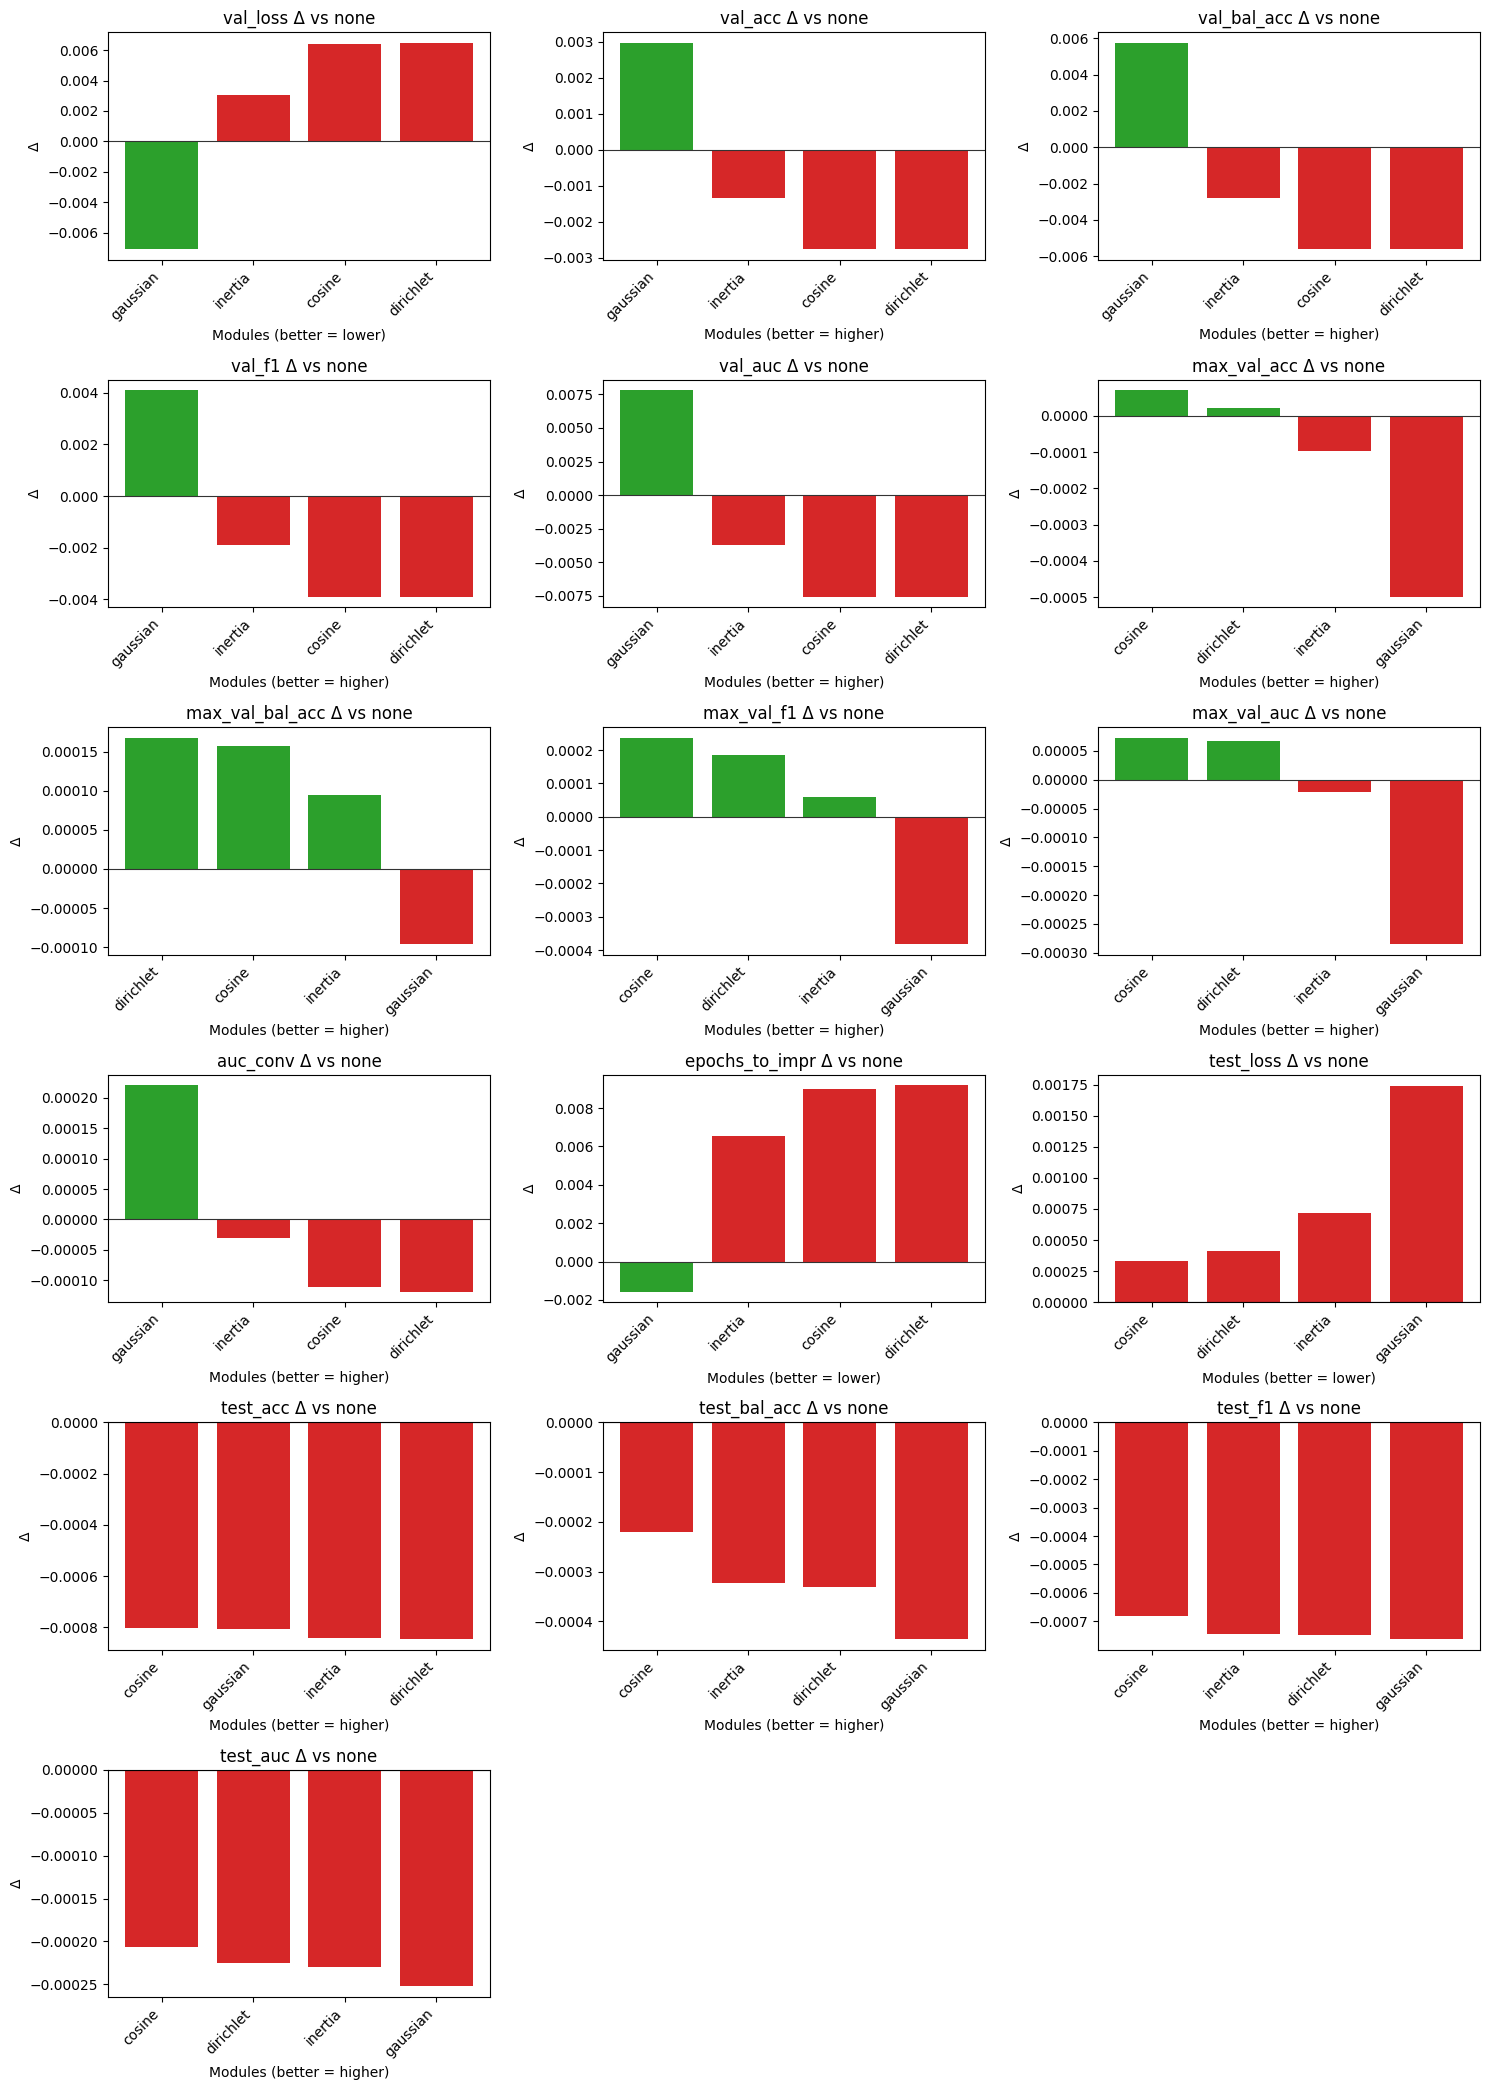

In [3]:
module_impact("adult", "mlp")

2025-11-02 17:01:03.386 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 118.
2025-11-02 17:01:03.388 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 118.
2025-11-02 17:01:03.388 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 118.
2025-11-02 17:01:03.388 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 152.
2025-11-02 17:01:03.388 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 152.
2025-11-02 17:01:03.389 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 152.
2025-11-02 17:01:03.389 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 152.
2025-11-02 17:01:03.389 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 152.
2025-11-02 17:01:03.389 | INFO     | metrics:auc_conv:69 - Convergence reached at index 50 out of 152.
2025-11-02 17:01:03.390 | INFO     | metrics:auc_conv:69 - Convergence re


Per-mode mean metrics:

[dirichlet]
  val_loss: 0.4080
  val_acc: 0.8025
  val_bal_acc: 0.8191
  val_f1: 0.7659
  val_auc: 0.9001
  max_val_acc: 0.7630
  max_val_bal_acc: 0.7826
  max_val_f1: 0.7248
  max_val_auc: 0.8655
  auc_conv: 0.7282
  epochs_to_impr: 0.1387
  test_loss: 0.4382
  test_acc: 0.7578
  test_bal_acc: 0.7877
  test_f1: 0.7249
  test_auc: 0.8675

[gaussian]
  val_loss: 0.4604
  val_acc: 0.7559
  val_bal_acc: 0.7516
  val_f1: 0.7087
  val_auc: 0.8395
  max_val_acc: 0.7627
  max_val_bal_acc: 0.7827
  max_val_f1: 0.7246
  max_val_auc: 0.8653
  auc_conv: 0.7287
  epochs_to_impr: 0.1236
  test_loss: 0.4391
  test_acc: 0.7574
  test_bal_acc: 0.7877
  test_f1: 0.7246
  test_auc: 0.8672

[inertia]
  val_loss: 0.4149
  val_acc: 0.7926
  val_bal_acc: 0.8092
  val_f1: 0.7554
  val_auc: 0.8939
  max_val_acc: 0.7626
  max_val_bal_acc: 0.7824
  max_val_f1: 0.7245
  max_val_auc: 0.8654
  auc_conv: 0.7279
  epochs_to_impr: 0.1364
  test_loss: 0.4393
  test_acc: 0.7572
  test_bal_acc: 

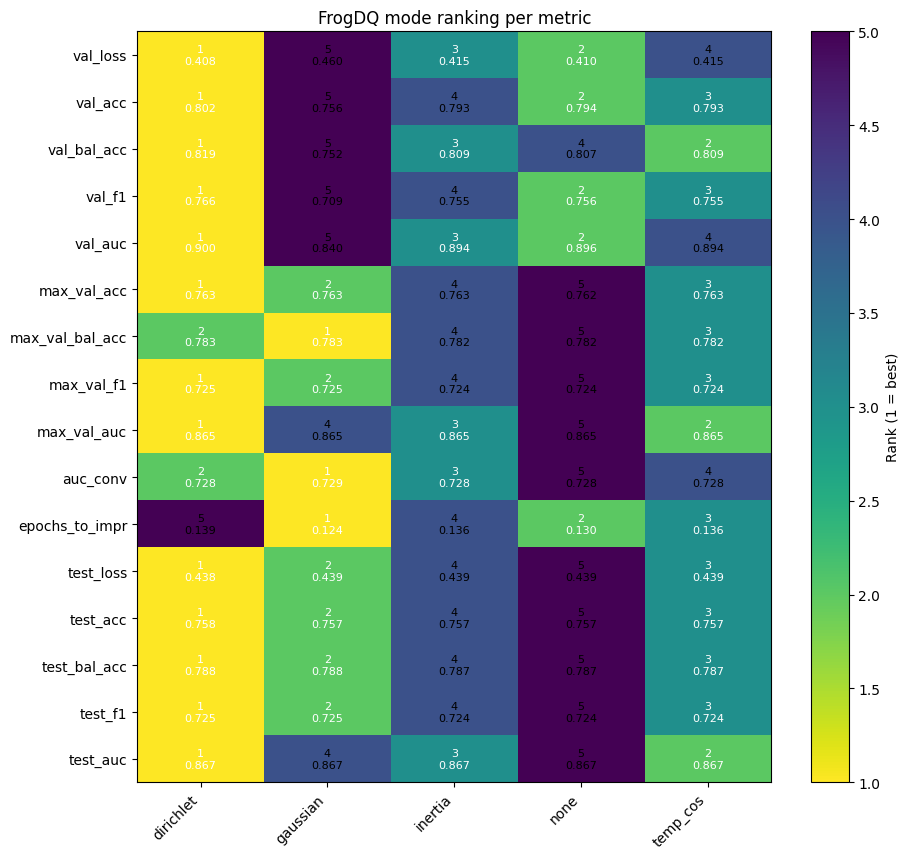

In [3]:
ranking(
    dataset="adult",
    model="linear",
)